<div style="border-bottom: 2px solid #B30033; padding-bottom: 15px; margin-bottom: 20px;">
  <h1><span style="color: #B30033;">CARDIS</span> — Hito 2</h1>
  <h2>Sección 2.4.7: Análisis de Sesgos Poblacionales y Equidad</h2>
  <p style="color: #888;">DISIA — Máster en Inteligencia Artificial — UCLM · Grupo 6</p>
</div>

## Índice

- [0. Carga de librerías y datos](#0)
- [1. Inventario de atributos protegidos y variables demográficas](#1)
- [2. Distribución por edad y prevalencia de riesgo](#2)
- [3. Patrones sistemáticos en los valores ausentes](#3)
- [4. Variabilidad entre centros hospitalarios](#4)
- [5. Análisis interseccional](#5)
- [6. Síntesis: implicaciones para la equidad del modelo](#6)

<a id="0"></a>
## 0. Carga de librerías y datos

Este cuaderno se centra exclusivamente en el análisis de sesgos poblacionales y equidad del dataset de CARDIS. El objetivo no es repetir el análisis exploratorio general (cubierto en el cuaderno de EDA), sino examinar los datos desde la perspectiva de la equidad: identificar qué subgrupos existen, cómo se distribuye el riesgo entre ellos, y si hay patrones sistemáticos que puedan provocar que el modelo futuro funcione peor para ciertos grupos de pacientes.

La motivación es directa: un sistema de apoyo a la decisión clínica que funcione significativamente peor para un subgrupo de pacientes no solo es técnicamente deficiente, sino éticamente inaceptable. Detectar estos riesgos antes del modelado permite tomar decisiones informadas de diseño.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración general
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

SEED = 42
FIGPATH = Path('../../hito2/figures')
FIGPATH.mkdir(parents=True, exist_ok=True)

# Paleta coherente con el resto de notebooks CARDIS
COLOR_BAJO  = '#2196F3'   # azul — riesgo bajo
COLOR_ALTO  = '#E53935'   # rojo — riesgo alto
COLOR_NEUTRO = '#78909C'  # gris azulado
PALETTE_RISK = {0: COLOR_BAJO, 1: COLOR_ALTO}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.size': 9,
})

In [2]:
# Carga de datos
df = pd.read_csv('../../data/raw/cardio_risk_train.csv')
print(f"Dataset de entrenamiento: {df.shape[0]:,} registros, {df.shape[1]} variables")
print(f"Prevalencia de riesgo alto: {df['riesgo_cv'].mean():.1%}")

Dataset de entrenamiento: 24,000 registros, 21 variables
Prevalencia de riesgo alto: 21.9%


<a id="1"></a>
---
## 1. Inventario de atributos protegidos y variables demográficas

El primer paso en cualquier análisis de equidad es identificar los atributos protegidos disponibles en el dataset. En la regulación europea (RGPD, AI Act) y en la literatura de fairness en ML, los atributos protegidos típicos incluyen sexo, edad, etnia, nivel socioeconómico, y ubicación geográfica.

Revisemos qué tenemos y, sobre todo, qué **no** tenemos.

In [3]:
# Variables del dataset y su relación con equidad
print("=== VARIABLES DEL DATASET ===")
print(f"Total de columnas: {len(df.columns)}")
print(f"Columnas: {list(df.columns)}")

# Buscar variables demográficas / protegidas
vars_demograficas = {
    'edad':                'Presente — atributo protegido (Age Discrimination Act)',
    'sexo':                'AUSENTE — no registrado en el dataset',
    'etnia/raza':          'AUSENTE — no registrado en el dataset',
    'hospital_origen':     'Presente — proxy geográfico/socioeconómico (20 centros)',
    'codigo_postal':       'Presente — proxy geográfico (791 valores únicos)',
}

print("\n=== ATRIBUTOS PROTEGIDOS Y PROXIES ===")
for var, estado in vars_demograficas.items():
    print(f"  {var:30s} → {estado}")

=== VARIABLES DEL DATASET ===
Total de columnas: 21
Columnas: ['id', 'fecha_visita', 'edad', 'altura_cm', 'peso_kg', 'imc', 'presion_sistolica_1', 'presion_sistolica_2', 'presion_sistolica_3', 'colesterol_total', 'hdl', 'ldl', 'glucosa_ayunas', 'fumador', 'actividad_fisica', 'antecedentes_familiares', 'codigo_postal', 'hospital_origen', 'notas_medicas', 'talla_zapato', 'riesgo_cv']

=== ATRIBUTOS PROTEGIDOS Y PROXIES ===
  edad                           → Presente — atributo protegido (Age Discrimination Act)
  sexo                           → AUSENTE — no registrado en el dataset
  etnia/raza                     → AUSENTE — no registrado en el dataset
  hospital_origen                → Presente — proxy geográfico/socioeconómico (20 centros)
  codigo_postal                  → Presente — proxy geográfico (791 valores únicos)


Este inventario revela un problema fundamental: **el dataset no contiene la variable sexo**. Esto impide cualquier análisis de equidad basado en género, que es uno de los ejes más relevantes en epidemiología cardiovascular. La literatura muestra consistentemente diferencias en la presentación, diagnóstico y pronóstico de enfermedades cardiovasculares entre hombres y mujeres (Mosca et al., 2011; Mehta et al., 2016). Sin esta variable, el modelo de CARDIS no podrá ser auditado por sesgo de género, lo que constituye una limitación seria que debe documentarse.

Tampoco disponemos de etnia ni nivel socioeconómico directo, aunque `hospital_origen` y `codigo_postal` pueden actuar como proxies indirectos de factores geográficos y, potencialmente, socioeconómicos.

En consecuencia, el análisis de equidad se centrará en tres ejes:
- **Edad**: único atributo protegido disponible directamente.
- **Centro hospitalario**: como proxy de posibles disparidades geográficas o de práctica clínica.
- **Patrones de datos ausentes**: como fuente de sesgo sistemático, dado que el EDA ya detectó tasas de *missing* muy heterogéneas.

<a id="2"></a>
---
## 2. Distribución por edad y prevalencia de riesgo

La edad es el principal factor de riesgo cardiovascular no modificable. Es esperable que la prevalencia de riesgo aumente con la edad; lo que nos interesa aquí es (a) si la distribución de edades en el dataset es equilibrada y (b) si el gradiente de riesgo es clínicamente plausible o muestra patrones sospechosos.

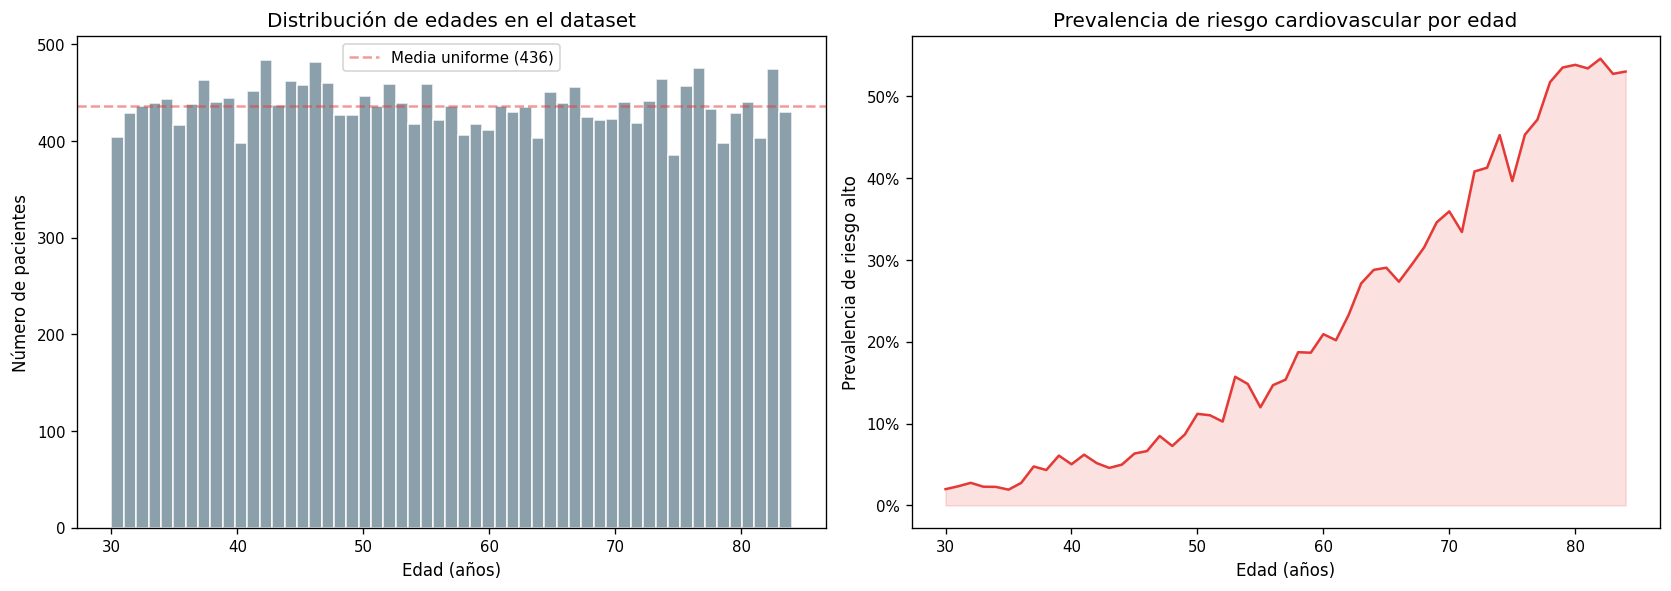

Rango de edad: 30 – 84 años
Distribución: aproximadamente uniforme (media por año ≈ 436 pacientes)


In [4]:
# Distribución de edades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: histograma de edades
axes[0].hist(df['edad'], bins=55, color=COLOR_NEUTRO, edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Número de pacientes')
axes[0].set_title('Distribución de edades en el dataset')
axes[0].axhline(y=len(df)/55, color='#E53935', linestyle='--', alpha=0.5, label=f'Media uniforme ({len(df)/55:.0f})')
axes[0].legend()

# Panel derecho: prevalencia de riesgo por edad
riesgo_por_edad = df.groupby('edad')['riesgo_cv'].mean()
axes[1].plot(riesgo_por_edad.index, riesgo_por_edad.values, color=COLOR_ALTO, linewidth=1.5)
axes[1].fill_between(riesgo_por_edad.index, riesgo_por_edad.values, alpha=0.15, color=COLOR_ALTO)
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Prevalencia de riesgo alto')
axes[1].set_title('Prevalencia de riesgo cardiovascular por edad')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(FIGPATH / 'equidad_edad_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Rango de edad: {df['edad'].min()} – {df['edad'].max()} años")
print(f"Distribución: aproximadamente uniforme (media por año ≈ {len(df)/55:.0f} pacientes)")

In [5]:
# Prevalencia por franjas de edad (quinquenios)
df['franja_edad'] = pd.cut(df['edad'], bins=[29, 39, 49, 55, 64, 74, 85],
                           labels=['30-39', '40-49', '50-55', '56-64', '65-74', '75-84'])

resumen_edad = df.groupby('franja_edad', observed=True).agg(
    pacientes=('riesgo_cv', 'count'),
    casos_alto_riesgo=('riesgo_cv', 'sum'),
    prevalencia=('riesgo_cv', 'mean')
).reset_index()

resumen_edad['pct_dataset'] = resumen_edad['pacientes'] / len(df)

print("=== PREVALENCIA DE RIESGO POR FRANJA DE EDAD ===")
print(resumen_edad.to_string(index=False, float_format=lambda x: f'{x:.1%}' if x < 1 else f'{x:.0f}'))

=== PREVALENCIA DE RIESGO POR FRANJA DE EDAD ===
franja_edad  pacientes  casos_alto_riesgo  prevalencia  pct_dataset
      30-39       4353                138         3.2%        18.1%
      40-49       4487                284         6.3%        18.7%
      50-55       2658                331        12.5%        11.1%
      56-64       3797                791        20.8%        15.8%
      65-74       4380               1527        34.9%        18.2%
      75-84       4325               2185        50.5%        18.0%


La distribución de edades es aproximadamente uniforme, lo que significa que no hay un grupo de edad infrarrepresentado en cantidad. Sin embargo, la prevalencia de riesgo alto muestra un gradiente marcado: pasa del 3% en menores de 40 años al 50% en mayores de 75.

Este gradiente es **clínicamente coherente** con lo que la epidemiología cardiovascular documenta (D'Agostino et al., 2008). Sin embargo, desde la perspectiva de equidad del modelo, plantea un problema práctico: el modelo tendrá muchos más ejemplos negativos en pacientes jóvenes y muchos más positivos en pacientes mayores. Si no se gestiona adecuadamente, esto puede provocar que el modelo aprenda un atajo basado en la edad en lugar de captar los factores de riesgo modificables (LDL, presión arterial, tabaquismo) que son los clínicamente accionables.

<a id="3"></a>
---
## 3. Patrones sistemáticos en los valores ausentes

El EDA general ya identificó las variables con valores ausentes: `glucosa_ayunas` (~43%), `notas_medicas` (~20%) y `fumador` (~9%). Lo que no se exploró es si esos *missing* siguen un patrón sistemático ligado a algún subgrupo. Si la probabilidad de tener un dato faltante depende de una característica del paciente (por ejemplo, su edad), el dato no es *Missing Completely at Random* (MCAR), y la imputación puede introducir sesgo.

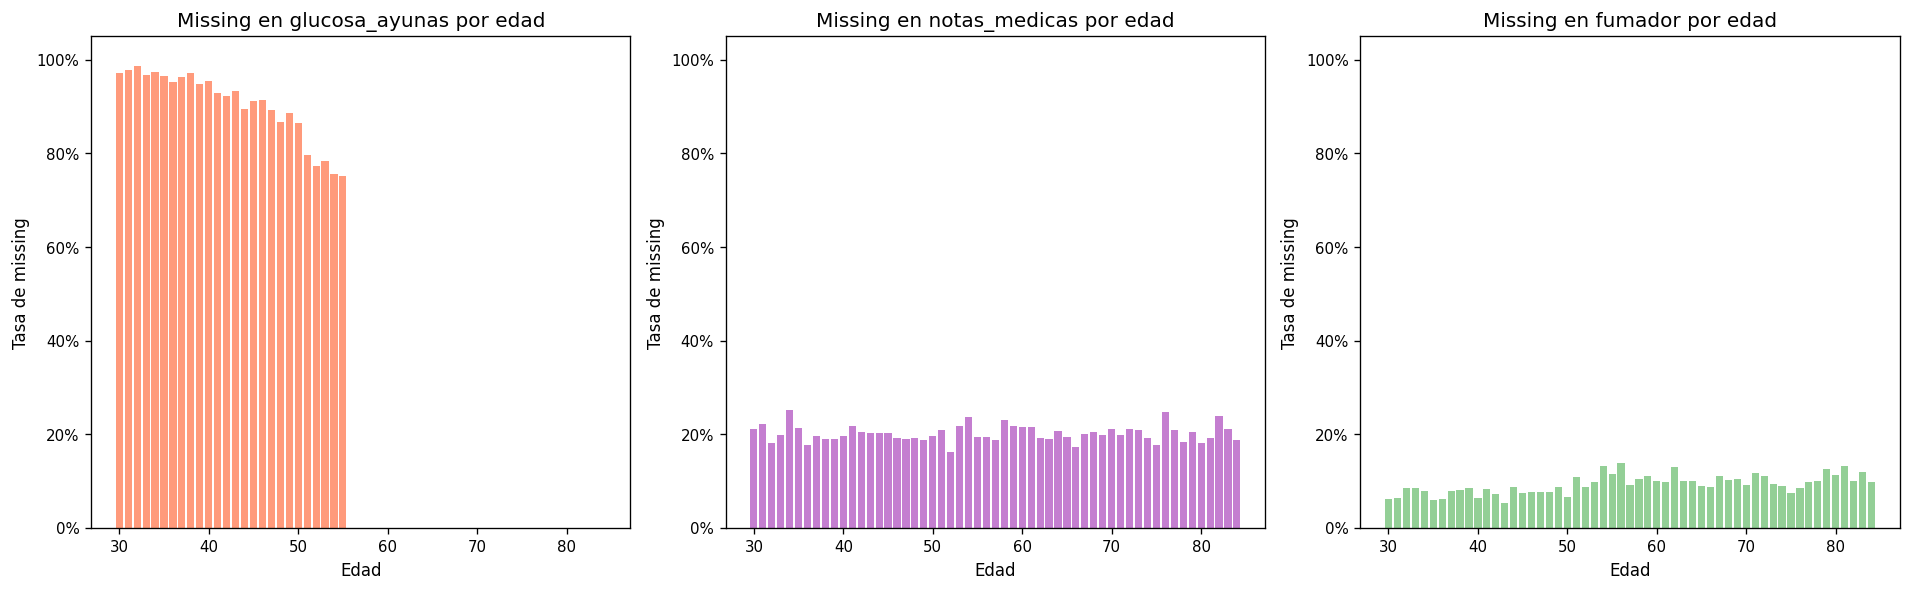

In [6]:
# Tasa de missing por variable y edad
df['gluc_missing'] = df['glucosa_ayunas'].isna().astype(int)
df['notas_missing'] = df['notas_medicas'].isna().astype(int)
df['fum_missing'] = df['fumador'].isna().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label, color in zip(
    axes,
    ['gluc_missing', 'notas_missing', 'fum_missing'],
    ['glucosa_ayunas', 'notas_medicas', 'fumador'],
    ['#FF7043', '#AB47BC', '#66BB6A']
):
    miss_by_age = df.groupby('edad')[col].mean()
    ax.bar(miss_by_age.index, miss_by_age.values, color=color, alpha=0.7, width=0.8)
    ax.set_xlabel('Edad')
    ax.set_ylabel('Tasa de missing')
    ax.set_title(f'Missing en {label} por edad')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGPATH / 'equidad_missing_por_edad.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cuantificar el patrón de glucosa
print("=== GLUCOSA_AYUNAS: TASA DE MISSING POR FRANJA DE EDAD ===")
miss_gluc = df.groupby('franja_edad', observed=True).agg(
    pacientes=('edad', 'count'),
    pct_missing_glucosa=('gluc_missing', 'mean'),
    pct_missing_notas=('notas_missing', 'mean'),
    pct_missing_fumador=('fum_missing', 'mean'),
).reset_index()
print(miss_gluc.to_string(index=False, float_format=lambda x: f'{x:.1%}' if x < 1 else f'{x:.0f}'))

# Corte exacto
print(f"\n→ Corte abrupto: de edad 55 ({df[df['edad']==55]['gluc_missing'].mean():.0%} missing) "
      f"a edad 56 ({df[df['edad']==56]['gluc_missing'].mean():.0%} missing)")
print(f"→ Pacientes sin glucosa registrada: {df['gluc_missing'].sum():,} de {len(df):,} ({df['gluc_missing'].mean():.1%})")

=== GLUCOSA_AYUNAS: TASA DE MISSING POR FRANJA DE EDAD ===
franja_edad  pacientes  pct_missing_glucosa  pct_missing_notas  pct_missing_fumador
      30-39       4353                96.8%              20.2%                 7.4%
      40-49       4487                91.1%              19.8%                 7.5%
      50-55       2658                78.8%              20.2%                10.0%
      56-64       3797                 0.0%              20.5%                10.8%
      65-74       4380                 0.0%              19.9%                 9.9%
      75-84       4325                 0.0%              20.3%                10.4%

→ Corte abrupto: de edad 55 (75% missing) a edad 56 (0% missing)
→ Pacientes sin glucosa registrada: 10,394 de 24,000 (43.3%)


Este es el hallazgo más relevante de todo el análisis de equidad: **la ausencia de glucosa en ayunas no es aleatoria, sino que depende casi determinísticamente de la edad del paciente**. Los pacientes menores de 56 años tienen entre el 75% y el 97% de valores faltantes en esta variable, mientras que a partir de los 56 años el missing es exactamente 0%.

Este patrón tiene una explicación clínica razonable: en la práctica real, las analíticas de glucosa basal no se solicitan rutinariamente a pacientes jóvenes sin factores de riesgo previos. Sin embargo, la glucosa en ayunas es uno de los predictores moderados del riesgo cardiovascular (r ≈ 0.29 con el target, según el EDA). Esto tiene dos consecuencias directas para la equidad del modelo:

1. **Pérdida de información diferencial**: el modelo dispondrá de menos señal predictiva para pacientes jóvenes. Al imputar la glucosa faltante con la mediana, se pierde toda variabilidad individual en ese grupo.

2. **Atenuación del riesgo en jóvenes**: un paciente joven con glucosa realmente elevada (prediabetes, diabetes tipo 2 precoz) no será detectado por esa vía porque el dato simplemente no existe. El modelo podría infraestimar el riesgo de ese subgrupo.

Por contraste, las variables `notas_medicas` y `fumador` muestran tasas de *missing* mucho más uniformes entre edades, lo que sugiere un mecanismo más cercano a MCAR para ellas.

<a id="4"></a>
---
## 4. Variabilidad entre centros hospitalarios

El dataset incluye 20 hospitales de origen. La pregunta desde equidad es: ¿la tasa de riesgo varía significativamente entre hospitales? Si es así, ¿refleja diferencias reales en la población atendida (case mix) o podría indicar sesgos de codificación, protocolos distintos o diferencias socioeconómicas del área de captación?

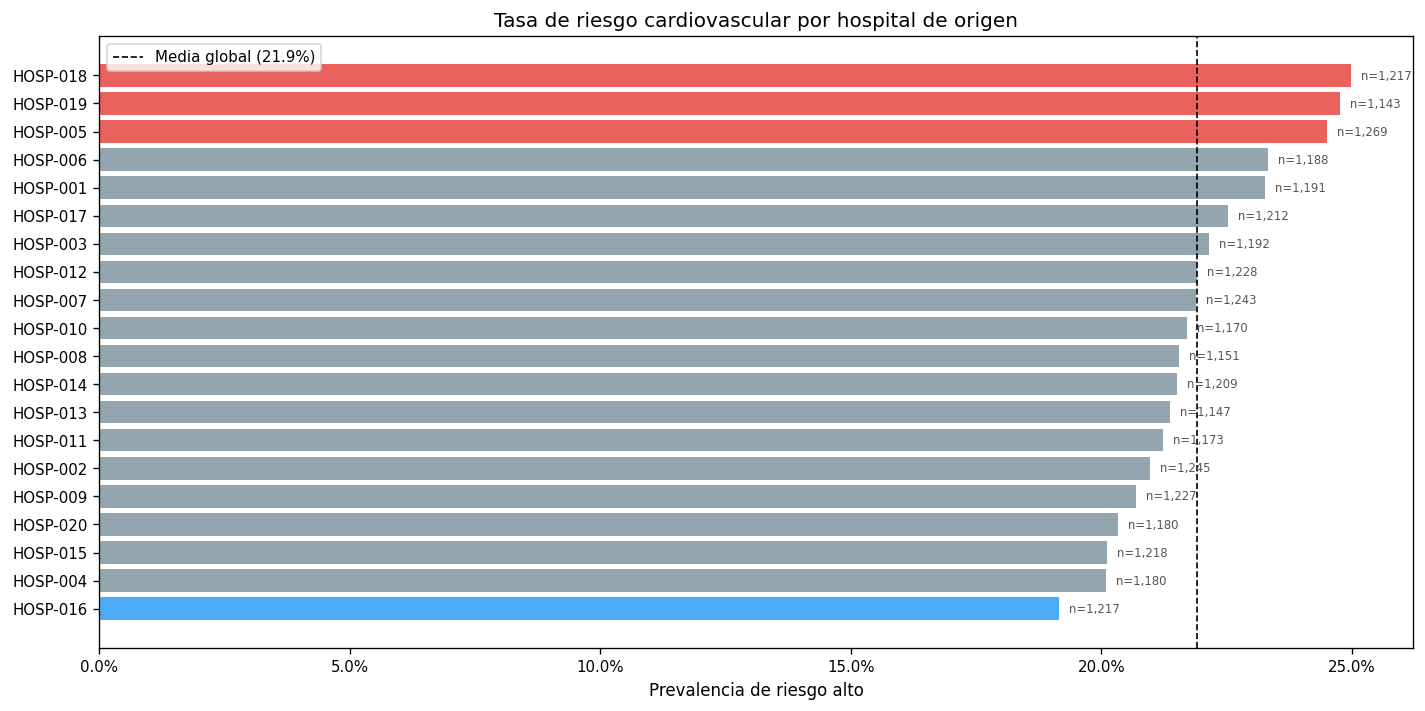

Rango de prevalencia: 19.1% – 25.0%
Diferencia máxima: 5.8%


In [8]:
# Riesgo por hospital
hosp_stats = df.groupby('hospital_origen').agg(
    n=('riesgo_cv', 'count'),
    prevalencia=('riesgo_cv', 'mean'),
    edad_media=('edad', 'mean'),
    edad_std=('edad', 'std'),
).sort_values('prevalencia').reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(hosp_stats['hospital_origen'], hosp_stats['prevalencia'],
               color=[COLOR_ALTO if p > 0.24 else COLOR_BAJO if p < 0.20 else COLOR_NEUTRO
                      for p in hosp_stats['prevalencia']],
               alpha=0.8)

# Línea de referencia: prevalencia global
prev_global = df['riesgo_cv'].mean()
ax.axvline(x=prev_global, color='black', linestyle='--', linewidth=1, label=f'Media global ({prev_global:.1%})')

ax.set_xlabel('Prevalencia de riesgo alto')
ax.set_title('Tasa de riesgo cardiovascular por hospital de origen')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()

# Anotaciones en las barras
for bar, n in zip(bars, hosp_stats['n']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'n={n:,}', va='center', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig(FIGPATH / 'equidad_riesgo_por_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Rango de prevalencia: {hosp_stats['prevalencia'].min():.1%} – {hosp_stats['prevalencia'].max():.1%}")
print(f"Diferencia máxima: {hosp_stats['prevalencia'].max() - hosp_stats['prevalencia'].min():.1%}")

In [9]:
# ¿La variabilidad se explica por diferencias de edad entre hospitales?
print("=== EDAD MEDIA POR HOSPITAL (ordenado por prevalencia) ===")
print(hosp_stats[['hospital_origen', 'prevalencia', 'edad_media', 'edad_std', 'n']].to_string(
    index=False, float_format=lambda x: f'{x:.2f}'))

corr_edad_riesgo = hosp_stats['prevalencia'].corr(hosp_stats['edad_media'])
print(f"\nCorrelación entre prevalencia y edad media del hospital: r = {corr_edad_riesgo:.3f}")

=== EDAD MEDIA POR HOSPITAL (ordenado por prevalencia) ===
hospital_origen  prevalencia  edad_media  edad_std    n
       HOSP-016         0.19       56.69     15.95 1217
       HOSP-004         0.20       56.78     15.82 1180
       HOSP-015         0.20       56.12     15.66 1218
       HOSP-020         0.20       56.79     15.80 1180
       HOSP-009         0.21       57.08     15.68 1227
       HOSP-002         0.21       56.71     16.13 1245
       HOSP-011         0.21       56.31     15.99 1173
       HOSP-013         0.21       56.86     16.08 1147
       HOSP-014         0.22       57.34     15.72 1209
       HOSP-008         0.22       56.99     15.84 1151
       HOSP-010         0.22       57.62     15.84 1170
       HOSP-007         0.22       57.44     15.77 1243
       HOSP-012         0.22       57.57     15.76 1228
       HOSP-003         0.22       57.38     16.00 1192
       HOSP-017         0.23       56.63     15.93 1212
       HOSP-001         0.23       56.68     

La prevalencia de riesgo alto varía entre el 19.1% y el 25.0% según el hospital, una diferencia de aproximadamente 6 puntos porcentuales. Aunque no es enorme en términos absolutos, puede tener implicaciones prácticas: si el modelo utiliza `hospital_origen` como variable predictiva (vía *target encoding*, como plantea el pipeline), estará codificando indirectamente estas diferencias.

La correlación entre la edad media por hospital y su prevalencia de riesgo permite valorar hasta qué punto la variabilidad es simplemente un efecto de composición etaria (hospitales que atienden a pacientes más mayores tendrán más riesgo). Si la correlación es baja, la variabilidad restante podría reflejar diferencias en protocolos, criterios de derivación o factores socioeconómicos del área — ninguno de los cuales debería influir idealmente en un predictor clínico de riesgo cardiovascular.

<a id="5"></a>
---
## 5. Análisis interseccional

La equidad no se analiza solo en un eje a la vez. Un modelo puede ser justo *en promedio* para cada grupo de edad y *en promedio* para cada hospital, pero fallar en la intersección de ambos (por ejemplo, pacientes jóvenes de un hospital concreto). En este apartado cruzamos los ejes disponibles para buscar subgrupos potencialmente vulnerables.

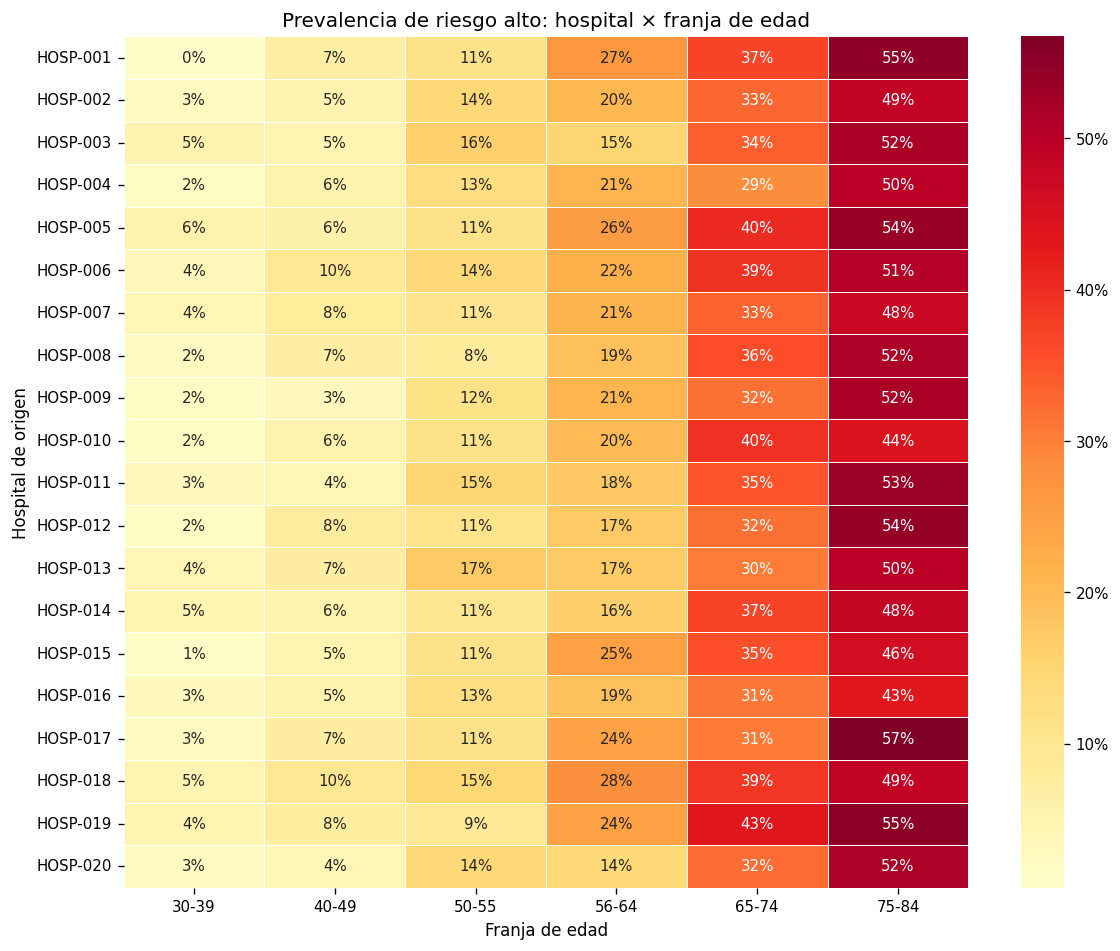

In [10]:
# Heatmap: prevalencia por franja de edad × hospital
pivot = df.pivot_table(values='riesgo_cv', index='hospital_origen',
                       columns='franja_edad', aggfunc='mean', observed=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'format': mticker.PercentFormatter(1.0)})
ax.set_title('Prevalencia de riesgo alto: hospital × franja de edad')
ax.set_xlabel('Franja de edad')
ax.set_ylabel('Hospital de origen')
plt.tight_layout()
plt.savefig(FIGPATH / 'equidad_interseccional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Tamaños de celda: ¿hay subgrupos con pocas observaciones?
pivot_n = df.pivot_table(values='riesgo_cv', index='hospital_origen',
                         columns='franja_edad', aggfunc='count', observed=True)

print("=== TAMAÑO DE SUBGRUPOS (hospital × franja de edad) ===")
print(f"Mínimo: {int(pivot_n.min().min())} pacientes")
print(f"Máximo: {int(pivot_n.max().max())} pacientes")
print(f"Media:  {pivot_n.values.mean():.0f} pacientes")
print(f"Subgrupos con < 50 pacientes: {(pivot_n < 50).sum().sum()} de {pivot_n.size} celdas")

=== TAMAÑO DE SUBGRUPOS (hospital × franja de edad) ===
Mínimo: 114 pacientes
Máximo: 261 pacientes
Media:  200 pacientes
Subgrupos con < 50 pacientes: 0 de 120 celdas


In [12]:
# Análisis cruzado: missing de glucosa × franja edad × riesgo real
# ¿Cuántos pacientes de alto riesgo son jóvenes sin glucosa?
jovenes = df[df['edad'] < 56].copy()
mayores = df[df['edad'] >= 56].copy()

print("=== IMPACTO DEL MISSING DE GLUCOSA EN LA DETECCIÓN DE RIESGO ===")
print(f"\nPacientes < 56 años: {len(jovenes):,} ({len(jovenes)/len(df):.1%} del dataset)")
print(f"  - De alto riesgo: {jovenes['riesgo_cv'].sum():,} ({jovenes['riesgo_cv'].mean():.1%})")
print(f"  - Sin glucosa registrada: {jovenes['gluc_missing'].sum():,} ({jovenes['gluc_missing'].mean():.1%})")
print(f"  - Alto riesgo Y sin glucosa: {jovenes[(jovenes['riesgo_cv']==1) & (jovenes['gluc_missing']==1)].shape[0]:,}")

print(f"\nPacientes ≥ 56 años: {len(mayores):,} ({len(mayores)/len(df):.1%} del dataset)")
print(f"  - De alto riesgo: {mayores['riesgo_cv'].sum():,} ({mayores['riesgo_cv'].mean():.1%})")
print(f"  - Sin glucosa registrada: {mayores['gluc_missing'].sum():,} ({mayores['gluc_missing'].mean():.1%})")

# ¿Antecedentes familiares y fumador compensan?
print("\n=== FACTORES DE RIESGO EN JÓVENES DE ALTO RIESGO SIN GLUCOSA ===")
jovenes_ar_no_gluc = jovenes[(jovenes['riesgo_cv']==1) & (jovenes['gluc_missing']==1)]
print(f"N = {len(jovenes_ar_no_gluc)}")
print(f"Tienen antecedentes familiares: {jovenes_ar_no_gluc['antecedentes_familiares'].mean():.1%}")
print(f"Son fumadores (no missing): {jovenes_ar_no_gluc['fumador'].dropna().mean():.1%}")

=== IMPACTO DEL MISSING DE GLUCOSA EN LA DETECCIÓN DE RIESGO ===

Pacientes < 56 años: 11,498 (47.9% del dataset)
  - De alto riesgo: 753 (6.5%)
  - Sin glucosa registrada: 10,394 (90.4%)
  - Alto riesgo Y sin glucosa: 495

Pacientes ≥ 56 años: 12,502 (52.1% del dataset)
  - De alto riesgo: 4,503 (36.0%)
  - Sin glucosa registrada: 0 (0.0%)

=== FACTORES DE RIESGO EN JÓVENES DE ALTO RIESGO SIN GLUCOSA ===
N = 495
Tienen antecedentes familiares: 25.3%
Son fumadores (no missing): 51.5%


El análisis interseccional refuerza el hallazgo de la sección 3. Existe un grupo concreto de pacientes que merece atención especial: **pacientes jóvenes de alto riesgo para los que no se dispone de glucosa en ayunas**. Estos pacientes son una minoría (la prevalencia de riesgo es baja en jóvenes), pero son precisamente los casos clínicamente más relevantes: personas jóvenes con riesgo cardiovascular elevado, donde una intervención precoz tendría el mayor impacto en años de vida ganados.

Para estos pacientes, el modelo deberá apoyarse en las variables que sí están disponibles (presión sistólica, LDL, colesterol total, antecedentes familiares, hábito tabáquico, keywords de notas médicas). La pregunta para el Hito 3 será si esa información es suficiente para identificarlos correctamente, o si el missing de glucosa causa una caída significativa del *recall* en este subgrupo.

<a id="6"></a>
---
## 6. Síntesis: implicaciones para la equidad del modelo

Recopilamos los hallazgos principales de este análisis y sus implicaciones directas para las fases de modelado y evaluación de CARDIS.

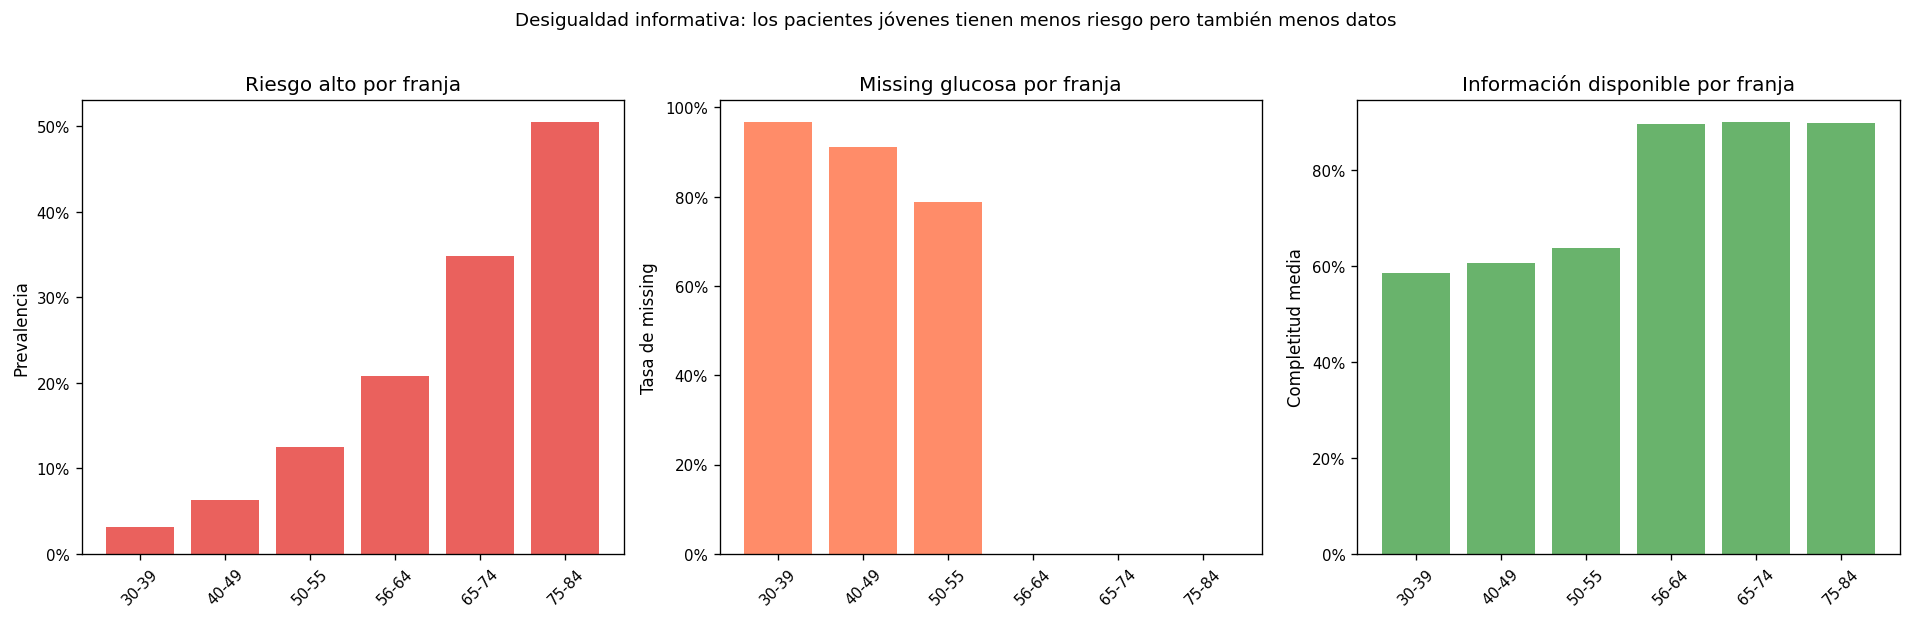

In [13]:
# Resumen visual: desigualdad informativa por edad
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: prevalencia de riesgo
risk_by_age = df.groupby('franja_edad', observed=True)['riesgo_cv'].mean()
axes[0].bar(range(len(risk_by_age)), risk_by_age.values, color=COLOR_ALTO, alpha=0.8)
axes[0].set_xticks(range(len(risk_by_age)))
axes[0].set_xticklabels(risk_by_age.index, rotation=45)
axes[0].set_ylabel('Prevalencia')
axes[0].set_title('Riesgo alto por franja')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Panel 2: missing de glucosa
miss_by_age = df.groupby('franja_edad', observed=True)['gluc_missing'].mean()
axes[1].bar(range(len(miss_by_age)), miss_by_age.values, color='#FF7043', alpha=0.8)
axes[1].set_xticks(range(len(miss_by_age)))
axes[1].set_xticklabels(miss_by_age.index, rotation=45)
axes[1].set_ylabel('Tasa de missing')
axes[1].set_title('Missing glucosa por franja')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Panel 3: "información disponible" (proporción de variables completas)
info_score = df.groupby('franja_edad', observed=True).apply(
    lambda g: 1 - g[['glucosa_ayunas','notas_medicas','fumador']].isna().mean().mean()
)
axes[2].bar(range(len(info_score)), info_score.values, color='#43A047', alpha=0.8)
axes[2].set_xticks(range(len(info_score)))
axes[2].set_xticklabels(info_score.index, rotation=45)
axes[2].set_ylabel('Completitud media')
axes[2].set_title('Información disponible por franja')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle('Desigualdad informativa: los pacientes jóvenes tienen menos riesgo pero también menos datos',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGPATH / 'equidad_sintesis_desigualdad_informativa.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgos principales

**1. Ausencia de la variable sexo.** El dataset no recoge el sexo del paciente, lo que impide auditar al modelo por sesgo de género. Dada la evidencia epidemiológica de diferencias cardiovasculares entre sexos, esta es una limitación que debe declararse explícitamente y considerarse en futuras versiones del servicio.

**2. Sesgo informativo dependiente de la edad.** La glucosa en ayunas, un predictor moderado del riesgo (r ≈ 0.29), falta en el 75-97% de los pacientes menores de 56 años y está completa a partir de esa edad. Este patrón no es aleatorio (no es MCAR), lo que significa que cualquier estrategia de imputación introducirá un sesgo diferencial por edad. El modelo dispondrá de menos información para los pacientes jóvenes.

**3. Gradiente de riesgo marcado.** La prevalencia pasa del 3% en menores de 40 al 50% en mayores de 75. Es clínicamente esperable, pero implica que el clasificador enfrentará un problema de desbalanceo *variable* según el subgrupo de edad. Las métricas globales (F1, AUC) pueden enmascarar un mal rendimiento en jóvenes.

**4. Variabilidad hospitalaria moderada.** La tasa de riesgo varía entre el 19% y el 25% según el hospital. Es necesario verificar si esta variabilidad se explica por composición demográfica o si el modelo aprende sesgos de práctica clínica.

### Conexión con las métricas de equidad (sección 2.7.3 de la memoria)

Estos hallazgos motivan directamente las métricas de fairness que se definirán en la memoria:

- **Equalized Odds por franja de edad**: la tasa de verdaderos positivos (recall) y de falsos positivos no debería variar sustancialmente entre grupos de edad. Si el modelo falla desproporcionadamente en jóvenes, estará perjudicando a quienes más se beneficiarían de una intervención precoz.

- **Análisis de rendimiento estratificado**: en el Hito 3, no bastará con reportar métricas globales. Se deberá evaluar el modelo separadamente para cada franja de edad, con especial atención al subgrupo <56 años (donde el missing de glucosa puede degradar el rendimiento).

- **Auditoría del efecto del hospital**: verificar que el *target encoding* de `hospital_origen` no codifique sesgos no clínicos en las predicciones.

In [14]:
# Limpieza de columnas auxiliares
df.drop(columns=['franja_edad', 'gluc_missing', 'notas_missing', 'fum_missing'], inplace=True, errors='ignore')

print("Notebook completado. Figuras exportadas en:", FIGPATH)

Notebook completado. Figuras exportadas en: ..\..\hito2\figures
